In [8]:
# ============================================================
# ABP movie maker from movie_trajectories_long.csv
#
# Input:
#   movie_trajectories_long.csv
#
# Output:
#   mp4 or gif movies:
#     1. physical trajectory in 2D with theta arrow
#     2. physical trajectory in 3D: x, y, time
#     3. production-chain movie: one saved trajectory per frame
# ============================================================

from pathlib import Path
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter
from mpl_toolkits.mplot3d import Axes3D


# ============================================================
# User settings
# ============================================================

PROJECT_DIR = Path("/home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep")
MOVIE_RUNS_ROOT = PROJECT_DIR / "data" / "movie_runs"

# Set to None to use newest movie run automatically.
# Or set explicitly, for example:
# MOVIE_RUN_DIR = MOVIE_RUNS_ROOT / "abp_movie_paths_123456"
MOVIE_RUN_DIR = None

CASE_CONTAINS = "D0p01"

# Choose one saved trajectory.
# None means choose automatically using ENDPOINT_X_MIN_FOR_SELECTION.
MOVIE_ID = None
ENDPOINT_X_MIN_FOR_SELECTION = -0.5   # use 0.5 if you want clear right-ending paths

# Movie output settings
SAVE_FORMAT = "mp4"   # "mp4" or "gif"
FPS = 20
DPI = 160

# Thin animation frames if movies are too slow/heavy.
PHYSICAL_FRAME_THIN = 1
PRODUCTION_FRAME_THIN = 1

# Plot limits
X_LIM = (-1.2, -0.5)
Y_LIM = (-1.5, 1.5)

# Theta arrow settings
ARROW_SCALE = 0.22

# For 3D movie
ROTATE_3D_VIEW = True


# ============================================================
# Helpers
# ============================================================

def newest_movie_run(movie_runs_root):
    runs = sorted(
        [p for p in movie_runs_root.glob("abp_movie_paths_*") if p.is_dir()],
        key=lambda p: p.stat().st_mtime,
    )
    if not runs:
        raise FileNotFoundError(f"No movie runs found in {movie_runs_root}")
    return runs[-1]


def find_case_movie_csv(movie_run_dir, case_contains=None):
    data_root = movie_run_dir / "combined" / "data"

    files = sorted(data_root.glob("abp_endpoint_conditioned_*/movie_trajectories_long.csv"))

    if not files:
        raise FileNotFoundError(
            f"No movie_trajectories_long.csv found under:\n  {data_root}"
        )

    if case_contains is None:
        return files[0]

    selected = [p for p in files if case_contains in p.parent.name]

    if not selected:
        print("Available movie cases:")
        for p in files:
            print("  ", p.parent.name)
        raise FileNotFoundError(f"No movie case containing {case_contains!r}")

    return selected[0]


def safe_name(s):
    return str(s).replace(".", "p").replace("-", "m").replace("/", "_")


def ffmpeg_available():
    return shutil.which("ffmpeg") is not None


def output_suffix():
    if SAVE_FORMAT == "mp4":
        if ffmpeg_available():
            return ".mp4"
        else:
            print("ffmpeg not found; falling back to GIF.")
            return ".gif"

    if SAVE_FORMAT == "gif":
        return ".gif"

    raise ValueError("SAVE_FORMAT must be 'mp4' or 'gif'.")


def get_writer(out_path, fps):
    out_path = Path(out_path)

    if out_path.suffix.lower() == ".mp4":
        return FFMpegWriter(fps=fps, bitrate=2500)

    if out_path.suffix.lower() == ".gif":
        return PillowWriter(fps=fps)

    raise ValueError("Movie output must end in .mp4 or .gif")

def load_movie_dataframe(csv_path):
    df = pd.read_csv(csv_path)

    needed = {
        "movie_id",
        "chain_id",
        "mcmc_step",
        "path_index",
        "physical_time",
        "x",
        "y",
        "theta",
        "cos_theta",
        "sin_theta",
        "endpoint_x",
        "endpoint_y",
    }

    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns in {csv_path}: {missing}")

    for col in needed:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=list(needed))

    df["movie_id"] = df["movie_id"].astype(int)
    df["chain_id"] = df["chain_id"].astype(int)
    df["mcmc_step"] = df["mcmc_step"].astype(int)
    df["path_index"] = df["path_index"].astype(int)

    df = df.sort_values(["movie_id", "path_index"]).reset_index(drop=True)
    return df


def choose_movie_id(df, movie_id=None, endpoint_x_min=0.0):
    ids = sorted(df["movie_id"].unique())

    if movie_id is not None:
        if int(movie_id) not in ids:
            raise ValueError(
                f"MOVIE_ID={movie_id} not found. "
                f"Available movie_id range: {ids[0]} ... {ids[-1]}"
            )
        return int(movie_id)

    summary = (
        df.groupby("movie_id", as_index=False)
        .agg(
            endpoint_x=("endpoint_x", "first"),
            endpoint_y=("endpoint_y", "first"),
            mcmc_step=("mcmc_step", "first"),
            n_points=("path_index", "count"),
        )
        .sort_values("movie_id")
    )

    candidates = summary[summary["endpoint_x"] > endpoint_x_min]

    if not candidates.empty:
        row = candidates.iloc[0]
        chosen = int(row["movie_id"])
        print(
            f"Selected movie_id={chosen} "
            f"with endpoint_x={row['endpoint_x']:.4g} > {endpoint_x_min}"
        )
        return chosen

    row = summary.iloc[0]
    chosen = int(row["movie_id"])
    print(
        f"No trajectory with endpoint_x>{endpoint_x_min} found. "
        f"Using first movie_id={chosen}."
    )
    return chosen


# ============================================================
# Movie 1: physical trajectory in 2D with theta arrow
# ============================================================

def make_physical_movie_2d(traj, out_path):
    x = traj["x"].to_numpy()
    y = traj["y"].to_numpy()
    t = traj["physical_time"].to_numpy()
    c = traj["cos_theta"].to_numpy()
    s = traj["sin_theta"].to_numpy()

    movie_id = int(traj["movie_id"].iloc[0])
    mcmc_step = int(traj["mcmc_step"].iloc[0])
    endpoint_x = float(traj["endpoint_x"].iloc[0])
    endpoint_y = float(traj["endpoint_y"].iloc[0])

    fig, ax = plt.subplots(figsize=(6.4, 5.3))

    ax.set_xlim(*X_LIM)
    ax.set_ylim(*Y_LIM)
    ax.set_xlabel("x(t)")
    ax.set_ylabel("y(t)")
    ax.set_title("Physical ABP trajectory: x(t), y(t), theta(t)")

    ax.axvline(0.0, linestyle="--", linewidth=1.0, alpha=0.45)
    ax.axhline(0.0, linestyle="--", linewidth=1.0, alpha=0.45)
    ax.grid(True, alpha=0.25)

    line, = ax.plot([], [], linewidth=1.6)
    point, = ax.plot([], [], marker="o", markersize=5)

    arrow = ax.quiver(
        [x[0]],
        [y[0]],
        [ARROW_SCALE * c[0]],
        [ARROW_SCALE * s[0]],
        angles="xy",
        scale_units="xy",
        scale=1.0,
        width=0.006,
    )

    text = ax.text(
        0.02,
        0.98,
        "",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
    )

    def update(i):
        line.set_data(x[: i + 1], y[: i + 1])
        point.set_data([x[i]], [y[i]])

        arrow.set_offsets(np.array([[x[i], y[i]]]))
        arrow.set_UVC(
            np.array([ARROW_SCALE * c[i]]),
            np.array([ARROW_SCALE * s[i]]),
        )

        text.set_text(
            f"movie_id = {movie_id}\n"
            f"MCMC step = {mcmc_step}\n"
            f"t = {t[i]:.3g}\n"
            f"x(T) = {endpoint_x:.3g}\n"
            f"y(T) = {endpoint_y:.3g}"
        )

        return line, point, arrow, text

    anim = FuncAnimation(
        fig,
        update,
        frames=len(traj),
        interval=1000 / FPS,
        blit=False,
    )

    out_path = Path(out_path)
    anim.save(out_path, writer=get_writer(out_path, FPS), dpi=DPI)
    plt.close(fig)

    print("Saved:", out_path)


# ============================================================
# Movie 2: physical trajectory in 3D: x, y, time
# ============================================================

def make_physical_movie_3d(traj, out_path):
    x = traj["x"].to_numpy()
    y = traj["y"].to_numpy()
    t = traj["physical_time"].to_numpy()

    movie_id = int(traj["movie_id"].iloc[0])
    mcmc_step = int(traj["mcmc_step"].iloc[0])
    endpoint_x = float(traj["endpoint_x"].iloc[0])
    endpoint_y = float(traj["endpoint_y"].iloc[0])

    fig = plt.figure(figsize=(6.6, 5.5))
    ax = fig.add_subplot(111, projection="3d")

    ax.set_xlim(*X_LIM)
    ax.set_ylim(*Y_LIM)
    ax.set_zlim(float(np.nanmin(t)), float(np.nanmax(t)))

    ax.set_xlabel("x(t)")
    ax.set_ylabel("y(t)")
    ax.set_zlabel("physical time")
    ax.set_title("Physical ABP trajectory in 3D")

    line, = ax.plot([], [], [], linewidth=1.5)
    point, = ax.plot([], [], [], marker="o", markersize=5)

    text = ax.text2D(
        0.02,
        0.96,
        "",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
    )

    def update(i):
        line.set_data(x[: i + 1], y[: i + 1])
        line.set_3d_properties(t[: i + 1])

        point.set_data([x[i]], [y[i]])
        point.set_3d_properties([t[i]])

        if ROTATE_3D_VIEW:
            ax.view_init(elev=24, azim=35 + 0.12 * i)
        else:
            ax.view_init(elev=24, azim=35)

        text.set_text(
            f"movie_id = {movie_id}\n"
            f"MCMC step = {mcmc_step}\n"
            f"t = {t[i]:.3g}\n"
            f"x(T) = {endpoint_x:.3g}\n"
            f"y(T) = {endpoint_y:.3g}"
        )

        return line, point, text

    anim = FuncAnimation(
        fig,
        update,
        frames=len(traj),
        interval=1000 / FPS,
        blit=False,
    )

    out_path = Path(out_path)
    anim.save(out_path, writer=get_writer(out_path, FPS), dpi=DPI)
    plt.close(fig)

    print("Saved:", out_path)


# ============================================================
# Movie 3: production-chain movie
# each frame = one saved trajectory from the selected chain
# ============================================================

def make_production_chain_movie_2d(df, out_path):
    summary = (
        df.groupby("movie_id", as_index=False)
        .agg(
            mcmc_step=("mcmc_step", "first"),
            endpoint_x=("endpoint_x", "first"),
            endpoint_y=("endpoint_y", "first"),
            n_points=("path_index", "count"),
        )
        .sort_values("mcmc_step")
        .reset_index(drop=True)
    )

    summary = summary.iloc[::PRODUCTION_FRAME_THIN].reset_index(drop=True)
    movie_ids = summary["movie_id"].to_numpy(dtype=int)

    fig, ax = plt.subplots(figsize=(6.4, 5.3))

    ax.set_xlim(*X_LIM)
    ax.set_ylim(*Y_LIM)
    ax.set_xlabel("x(t)")
    ax.set_ylabel("y(t)")
    ax.set_title("Production chain: saved trajectory snapshots")

    ax.axvline(0.0, linestyle="--", linewidth=1.0, alpha=0.45)
    ax.axhline(0.0, linestyle="--", linewidth=1.0, alpha=0.45)
    ax.grid(True, alpha=0.25)

    line, = ax.plot([], [], linewidth=1.5)
    start_point, = ax.plot([], [], marker="o", markersize=4)
    end_point, = ax.plot([], [], marker="s", markersize=5)

    text = ax.text(
        0.02,
        0.98,
        "",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
    )

    def update(frame):
        movie_id = movie_ids[frame]
        tr = df[df["movie_id"] == movie_id].sort_values("path_index")

        x = tr["x"].to_numpy()
        y = tr["y"].to_numpy()

        line.set_data(x, y)
        start_point.set_data([x[0]], [y[0]])
        end_point.set_data([x[-1]], [y[-1]])

        text.set_text(
            f"frame = {frame + 1}/{len(movie_ids)}\n"
            f"movie_id = {movie_id}\n"
            f"MCMC step = {int(tr['mcmc_step'].iloc[0])}\n"
            f"x(T) = {tr['endpoint_x'].iloc[0]:.3g}\n"
            f"y(T) = {tr['endpoint_y'].iloc[0]:.3g}"
        )

        return line, start_point, end_point, text

    anim = FuncAnimation(
        fig,
        update,
        frames=len(movie_ids),
        interval=1000 / FPS,
        blit=False,
    )

    out_path = Path(out_path)
    anim.save(out_path, writer=get_writer(out_path, FPS), dpi=DPI)
    plt.close(fig)

    print("Saved:", out_path)


# ============================================================
# Main execution
# ============================================================

if MOVIE_RUN_DIR is None:
    MOVIE_RUN_DIR = newest_movie_run(MOVIE_RUNS_ROOT)

print("Using movie run:")
print(" ", MOVIE_RUN_DIR)

csv_path = find_case_movie_csv(MOVIE_RUN_DIR, CASE_CONTAINS)
print("Using movie CSV:")
print(" ", csv_path)

case_name = csv_path.parent.name
movie_out_dir = MOVIE_RUN_DIR / "movies" / case_name
movie_out_dir.mkdir(parents=True, exist_ok=True)

df = load_movie_dataframe(csv_path)

print("Case:", case_name)
print("Saved production trajectories:", df["movie_id"].nunique())
print("Total rows:", len(df))

endpoint_summary = (
    df.groupby("movie_id", as_index=False)
    .agg(
        mcmc_step=("mcmc_step", "first"),
        endpoint_x=("endpoint_x", "first"),
        endpoint_y=("endpoint_y", "first"),
        n_points=("path_index", "count"),
    )
)

print("Endpoint x range:")
print("  min:", endpoint_summary["endpoint_x"].min())
print("  max:", endpoint_summary["endpoint_x"].max())

selected_movie_id = choose_movie_id(
    df,
    movie_id=MOVIE_ID,
    endpoint_x_min=ENDPOINT_X_MIN_FOR_SELECTION,
)

traj = (
    df[df["movie_id"] == selected_movie_id]
    .sort_values("path_index")
    .iloc[::PHYSICAL_FRAME_THIN]
    .reset_index(drop=True)
)

print("Selected physical trajectory:")
print("  movie_id:", selected_movie_id)
print("  mcmc_step:", int(traj["mcmc_step"].iloc[0]))
print("  endpoint_x:", float(traj["endpoint_x"].iloc[0]))
print("  endpoint_y:", float(traj["endpoint_y"].iloc[0]))
print("  physical points:", len(traj))

suffix = output_suffix()

out_2d = movie_out_dir / f"{case_name}_movie_id_{selected_movie_id}_physical_xy_theta{suffix}"
out_3d = movie_out_dir / f"{case_name}_movie_id_{selected_movie_id}_physical_xyt_3d{suffix}"
out_prod = movie_out_dir / f"{case_name}_production_chain_xy{suffix}"

make_physical_movie_2d(traj, out_2d)
make_physical_movie_3d(traj, out_3d)
make_production_chain_movie_2d(df, out_prod)

print("Done. Movies saved in:")
print(" ", movie_out_dir)

Using movie run:
  /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/movie_runs/abp_movie_paths_1374611
Using movie CSV:
  /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/movie_runs/abp_movie_paths_1374611/combined/data/abp_endpoint_conditioned_D0p01/movie_trajectories_long.csv
Case: abp_endpoint_conditioned_D0p01
Saved production trajectories: 312
Total rows: 78312
Endpoint x range:
  min: -0.7896643026260155
  max: -0.1128680073075796
Selected movie_id=16 with endpoint_x=-0.4653 > -0.5
Selected physical trajectory:
  movie_id: 16
  mcmc_step: 80000
  endpoint_x: -0.4653334528352624
  endpoint_y: -0.1839151501501082
  physical points: 251
ffmpeg not found; falling back to GIF.
Saved: /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/movie_runs/abp_movie_paths_1374611/movies/abp_endpoint_conditioned_D0p01/abp_endpoint_conditioned_D0p01_movie_id_16_physical_xy_theta.gif
Saved: /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/movie_runs/abp_movi

Using movie run:
  /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/movie_runs/abp_movie_paths_1374611
Using case:
  abp_endpoint_conditioned_D0p01
Using CSV:
  /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/movie_runs/abp_movie_paths_1374611/combined/data/abp_endpoint_conditioned_D0p01/movie_trajectories_long.csv
Selected 312 trajectories for overlay.
movie_id range: 1 to 312


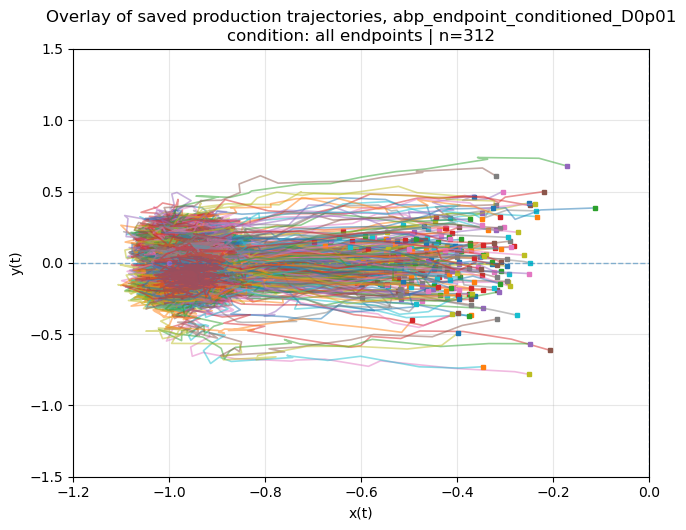

In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# User settings
# ============================================================

PROJECT_DIR = Path("/home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep")
MOVIE_RUNS_ROOT = PROJECT_DIR / "data" / "movie_runs"

# Use newest run automatically if None
MOVIE_RUN_DIR = None

# Choose case by substring, e.g. "D0p05", "D0p01", "D0p005"
CASE_CONTAINS = "D0p01"

# How many trajectories to overlay
N_TRAJ = 500

# Endpoint selection:
#   "all"      -> no endpoint filter
#   "x_gt0"    -> x(T) > 0
#   "x_gt0p5"  -> x(T) > 0.5
ENDPOINT_MODE = "all"

# Optional extra thinning in the plotted points of each trajectory
PLOT_TIME_THIN = 1

# Plot limits
X_LIM = (-1.2, 0)
Y_LIM = (-1.5, 1.5)

# Save / show
SAVE_FIG = False
SHOW_FIG = True
FIG_DPI = 180


# ============================================================
# Helpers
# ============================================================

def newest_movie_run(movie_runs_root):
    runs = sorted(
        [p for p in movie_runs_root.glob("abp_movie_paths_*") if p.is_dir()],
        key=lambda p: p.stat().st_mtime,
    )
    if not runs:
        raise FileNotFoundError(f"No movie runs found in {movie_runs_root}")
    return runs[-1]


def find_case_movie_csv(movie_run_dir, case_contains=None):
    data_root = movie_run_dir / "combined" / "data"
    files = sorted(data_root.glob("abp_endpoint_conditioned_*/movie_trajectories_long.csv"))

    if not files:
        raise FileNotFoundError(f"No movie_trajectories_long.csv found under {data_root}")

    if case_contains is None:
        return files[0]

    selected = [p for p in files if case_contains in p.parent.name]
    if not selected:
        print("Available cases:")
        for p in files:
            print("  ", p.parent.name)
        raise FileNotFoundError(f"No case containing {case_contains!r}")

    return selected[0]


def load_movie_dataframe(csv_path):
    df = pd.read_csv(csv_path)

    needed = {
        "movie_id",
        "chain_id",
        "mcmc_step",
        "path_index",
        "physical_time",
        "x",
        "y",
        "endpoint_x",
        "endpoint_y",
    }

    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns in {csv_path}: {missing}")

    for col in needed:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=list(needed)).copy()
    df["movie_id"] = df["movie_id"].astype(int)
    df["chain_id"] = df["chain_id"].astype(int)
    df["mcmc_step"] = df["mcmc_step"].astype(int)
    df["path_index"] = df["path_index"].astype(int)

    df = df.sort_values(["movie_id", "path_index"]).reset_index(drop=True)
    return df


def select_movie_ids(summary_df, endpoint_mode="all", n_traj=20):
    work = summary_df.copy()

    if endpoint_mode == "all":
        pass
    elif endpoint_mode == "x_gt0":
        work = work[work["endpoint_x"] > 0.0]
    elif endpoint_mode == "x_gt0p5":
        work = work[work["endpoint_x"] > 0.5]
    else:
        raise ValueError("ENDPOINT_MODE must be one of: 'all', 'x_gt0', 'x_gt0p5'")

    if work.empty:
        raise ValueError(f"No saved trajectories satisfy endpoint condition: {endpoint_mode}")

    work = work.sort_values("mcmc_step").reset_index(drop=True)

    if len(work) <= n_traj:
        return work["movie_id"].tolist()

    # choose approximately evenly spaced trajectories in production time
    idx = np.unique(np.round(np.linspace(0, len(work) - 1, n_traj)).astype(int))
    return work.iloc[idx]["movie_id"].tolist()


def endpoint_text(mode):
    if mode == "all":
        return "all endpoints"
    if mode == "x_gt0":
        return "x(T) > 0"
    if mode == "x_gt0p5":
        return "x(T) > 0.5"
    return mode


# ============================================================
# Load data
# ============================================================

if MOVIE_RUN_DIR is None:
    MOVIE_RUN_DIR = newest_movie_run(MOVIE_RUNS_ROOT)

csv_path = find_case_movie_csv(MOVIE_RUN_DIR, CASE_CONTAINS)
case_name = csv_path.parent.name

print("Using movie run:")
print(" ", MOVIE_RUN_DIR)
print("Using case:")
print(" ", case_name)
print("Using CSV:")
print(" ", csv_path)

df = load_movie_dataframe(csv_path)

summary = (
    df.groupby("movie_id", as_index=False)
    .agg(
        chain_id=("chain_id", "first"),
        mcmc_step=("mcmc_step", "first"),
        endpoint_x=("endpoint_x", "first"),
        endpoint_y=("endpoint_y", "first"),
        n_points=("path_index", "count"),
    )
    .sort_values("mcmc_step")
    .reset_index(drop=True)
)

selected_ids = select_movie_ids(summary, endpoint_mode=ENDPOINT_MODE, n_traj=N_TRAJ)

print(f"Selected {len(selected_ids)} trajectories for overlay.")
print("movie_id range:", min(selected_ids), "to", max(selected_ids))


# ============================================================
# Overlay plot
# ============================================================

fig, ax = plt.subplots(figsize=(6.8, 5.4))

for movie_id in selected_ids:
    tr = df[df["movie_id"] == movie_id].sort_values("path_index")
    tr = tr.iloc[::PLOT_TIME_THIN]

    x = tr["x"].to_numpy()
    y = tr["y"].to_numpy()

    # draw full trajectory
    ax.plot(x, y, alpha=0.5, linewidth=1.2)

    # mark start and end
    ax.plot(x[0], y[0], marker="o", markersize=3)
    ax.plot(x[-1], y[-1], marker="s", markersize=3)

ax.axvline(0.0, linestyle="--", linewidth=1.0, alpha=0.5)
ax.axhline(0.0, linestyle="--", linewidth=1.0, alpha=0.5)

ax.set_xlim(*X_LIM)
ax.set_ylim(*Y_LIM)
ax.set_xlabel("x(t)")
ax.set_ylabel("y(t)")
ax.set_title(
    f"Overlay of saved production trajectories, {case_name}\n"
    f"condition: {endpoint_text(ENDPOINT_MODE)} | n={len(selected_ids)}"
)
ax.grid(True, alpha=0.3)

fig.tight_layout()

if SAVE_FIG:
    out_dir = MOVIE_RUN_DIR / "movies" / case_name
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f"{case_name}_overlay_{ENDPOINT_MODE}_n{len(selected_ids)}.png"
    fig.savefig(out_path, dpi=FIG_DPI, bbox_inches="tight")
    print("Saved:", out_path)

if SHOW_FIG:
    plt.show()
else:
    plt.close(fig)

In [1]:
# ============================================================
# ABP movie maker from movie_trajectories_long.csv
#
# Outputs only:
#   1. physical trajectory in 2D with theta arrow
#   2. production Markov-chain movie:
#        top: saved trajectory snapshot
#        bottom: endpoint x(T) along the saved MCMC chain
# ============================================================

from pathlib import Path
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter


# ============================================================
# User settings
# ============================================================

PROJECT_DIR = Path("/home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep")
MOVIE_RUNS_ROOT = PROJECT_DIR / "data" / "movie_runs"

# None means newest movie run automatically.
MOVIE_RUN_DIR = None

# Choose case by substring.
CASE_CONTAINS = "D0p05"      # try "D0p1", "D0p05", "D0p01"

# Which saved production chain to visualize.
CHAIN_ID = 1

# Output settings.
SAVE_FORMAT = "mp4"          # "mp4" or "gif"
FPS = 20
DPI = 150

# Physical movie selection.
# Options:
#   None                 -> automatic
#   integer movie_id      -> explicit trajectory
PHYSICAL_MOVIE_ID = None

# Automatic physical trajectory choice:
#   "max_endpoint_x"      -> choose trajectory with largest x(T)
#   "first_right"         -> first trajectory with x(T) > PHYSICAL_ENDPOINT_MIN
#   "middle_of_segment"   -> middle frame of selected Markov segment
PHYSICAL_SELECTION_MODE = "max_endpoint_x"
PHYSICAL_ENDPOINT_MIN = 0.5

# Frame thinning for physical movie.
PHYSICAL_FRAME_THIN = 1

# Markov-chain movie settings.
# Each frame is one saved production trajectory.
MARKOV_FRAME_THIN = 1
MAX_MARKOV_FRAMES = 2500

# Try to focus the Markov-chain movie on a roundtrip-like segment.
USE_ROUNDTRIP_SEGMENT = True

# Visual roundtrip thresholds for endpoint x(T).
# These are for plotting/segment choice, not for changing the simulation.
ROUNDTRIP_LEFT_LEVEL = -1.0
ROUNDTRIP_RIGHT_LEVEL = 0.5

# Plot limits for trajectory snapshots.
# Use wider x-limits if you want to see full left/right movement.
X_LIM = (-1.5, 1.5)
Y_LIM = (-3.0, 3.0)

# Theta arrow length. Direction is physical; length is visual.
ARROW_SCALE = 0.22


# ============================================================
# Helpers
# ============================================================

def newest_movie_run(movie_runs_root):
    runs = sorted(
        [p for p in movie_runs_root.glob("abp_movie_paths_*") if p.is_dir()],
        key=lambda p: p.stat().st_mtime,
    )
    if not runs:
        raise FileNotFoundError(f"No movie runs found in {movie_runs_root}")
    return runs[-1]


def find_case_movie_csv(movie_run_dir, case_contains=None):
    data_root = movie_run_dir / "combined" / "data"
    files = sorted(data_root.glob("abp_endpoint_conditioned_*/movie_trajectories_long.csv"))

    if not files:
        raise FileNotFoundError(
            f"No movie_trajectories_long.csv found under:\n  {data_root}"
        )

    if case_contains is None:
        return files[0]

    selected = [p for p in files if case_contains in p.parent.name]

    if not selected:
        print("Available movie cases:")
        for p in files:
            print("  ", p.parent.name)
        raise FileNotFoundError(f"No movie case containing {case_contains!r}")

    return selected[0]


def ffmpeg_available():
    return shutil.which("ffmpeg") is not None


def output_suffix():
    if SAVE_FORMAT == "mp4":
        if ffmpeg_available():
            return ".mp4"
        print("ffmpeg not found; falling back to GIF.")
        return ".gif"

    if SAVE_FORMAT == "gif":
        return ".gif"

    raise ValueError("SAVE_FORMAT must be 'mp4' or 'gif'.")


def get_writer(out_path, fps):
    out_path = Path(out_path)

    if out_path.suffix.lower() == ".mp4":
        return FFMpegWriter(fps=fps, bitrate=2500)

    if out_path.suffix.lower() == ".gif":
        return PillowWriter(fps=fps)

    raise ValueError("Movie output must end in .mp4 or .gif")


def load_movie_dataframe(csv_path):
    df = pd.read_csv(csv_path)

    needed = {
        "movie_id",
        "chain_id",
        "mcmc_step",
        "path_index",
        "physical_time",
        "x",
        "y",
        "theta",
        "cos_theta",
        "sin_theta",
        "endpoint_x",
        "endpoint_y",
    }

    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns in {csv_path}: {missing}")

    for col in needed:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=list(needed)).copy()

    df["movie_id"] = df["movie_id"].astype(int)
    df["chain_id"] = df["chain_id"].astype(int)
    df["mcmc_step"] = df["mcmc_step"].astype(int)
    df["path_index"] = df["path_index"].astype(int)

    df = df.sort_values(["chain_id", "movie_id", "path_index"]).reset_index(drop=True)
    return df


def make_summary(df):
    return (
        df.groupby(["chain_id", "movie_id"], as_index=False)
        .agg(
            mcmc_step=("mcmc_step", "first"),
            endpoint_x=("endpoint_x", "first"),
            endpoint_y=("endpoint_y", "first"),
            n_points=("path_index", "count"),
        )
        .sort_values(["chain_id", "mcmc_step"])
        .reset_index(drop=True)
    )


def choose_roundtrip_segment(summary):
    """
    Select a visible left -> right -> left or right -> left -> right segment
    using saved movie snapshots.

    This is a plotting choice only.
    """
    s = summary.sort_values("mcmc_step").reset_index(drop=True)
    x = s["endpoint_x"].to_numpy()

    left = x < ROUNDTRIP_LEFT_LEVEL
    right = x > ROUNDTRIP_RIGHT_LEVEL

    if not left.any() or not right.any():
        print("No full left/right threshold hits found. Using full saved chain.")
        return s

    # Try left -> right -> left.
    left_indices = np.where(left)[0]
    right_indices = np.where(right)[0]

    for i0 in left_indices:
        right_after = right_indices[right_indices > i0]
        if len(right_after) == 0:
            continue
        i1 = right_after[0]

        left_after = left_indices[left_indices > i1]
        if len(left_after) == 0:
            continue
        i2 = left_after[0]

        pad = max(5, int(0.05 * (i2 - i0 + 1)))
        a = max(0, i0 - pad)
        b = min(len(s) - 1, i2 + pad)

        print(
            "Selected left -> right -> left segment:",
            f"indices {a}:{b},",
            f"steps {s.loc[a, 'mcmc_step']} to {s.loc[b, 'mcmc_step']}",
        )
        return s.iloc[a:b + 1].reset_index(drop=True)

    # Try right -> left -> right.
    for i0 in right_indices:
        left_after = left_indices[left_indices > i0]
        if len(left_after) == 0:
            continue
        i1 = left_after[0]

        right_after = right_indices[right_indices > i1]
        if len(right_after) == 0:
            continue
        i2 = right_after[0]

        pad = max(5, int(0.05 * (i2 - i0 + 1)))
        a = max(0, i0 - pad)
        b = min(len(s) - 1, i2 + pad)

        print(
            "Selected right -> left -> right segment:",
            f"indices {a}:{b},",
            f"steps {s.loc[a, 'mcmc_step']} to {s.loc[b, 'mcmc_step']}",
        )
        return s.iloc[a:b + 1].reset_index(drop=True)

    print("No complete roundtrip-like segment found. Using full saved chain.")
    return s


def thin_summary_for_movie(summary):
    s = summary.sort_values("mcmc_step").reset_index(drop=True)

    if MARKOV_FRAME_THIN > 1:
        s = s.iloc[::MARKOV_FRAME_THIN].reset_index(drop=True)

    if len(s) > MAX_MARKOV_FRAMES:
        idx = np.unique(np.round(np.linspace(0, len(s) - 1, MAX_MARKOV_FRAMES)).astype(int))
        s = s.iloc[idx].reset_index(drop=True)

    return s


def choose_physical_movie_id(summary_segment):
    s = summary_segment.sort_values("mcmc_step").reset_index(drop=True)

    if PHYSICAL_MOVIE_ID is not None:
        return int(PHYSICAL_MOVIE_ID)

    if PHYSICAL_SELECTION_MODE == "max_endpoint_x":
        row = s.iloc[s["endpoint_x"].to_numpy().argmax()]
        return int(row["movie_id"])

    if PHYSICAL_SELECTION_MODE == "first_right":
        candidates = s[s["endpoint_x"] > PHYSICAL_ENDPOINT_MIN]
        if not candidates.empty:
            return int(candidates.iloc[0]["movie_id"])
        row = s.iloc[s["endpoint_x"].to_numpy().argmax()]
        return int(row["movie_id"])

    if PHYSICAL_SELECTION_MODE == "middle_of_segment":
        row = s.iloc[len(s) // 2]
        return int(row["movie_id"])

    raise ValueError("Unknown PHYSICAL_SELECTION_MODE")


# ============================================================
# Movie 1: physical trajectory in 2D with theta arrow
# ============================================================

def make_physical_movie_2d(traj, out_path):
    x = traj["x"].to_numpy()
    y = traj["y"].to_numpy()
    t = traj["physical_time"].to_numpy()
    c = traj["cos_theta"].to_numpy()
    s = traj["sin_theta"].to_numpy()

    movie_id = int(traj["movie_id"].iloc[0])
    chain_id = int(traj["chain_id"].iloc[0])
    mcmc_step = int(traj["mcmc_step"].iloc[0])
    endpoint_x = float(traj["endpoint_x"].iloc[0])
    endpoint_y = float(traj["endpoint_y"].iloc[0])

    fig, ax = plt.subplots(figsize=(6.4, 5.3))

    ax.set_xlim(*X_LIM)
    ax.set_ylim(*Y_LIM)
    ax.set_xlabel("x(t)")
    ax.set_ylabel("y(t)")
    ax.set_title("Physical ABP trajectory inside one sampled Markov state")

    ax.axvline(0.0, linestyle="--", linewidth=1.0, alpha=0.45)
    ax.axhline(0.0, linestyle="--", linewidth=1.0, alpha=0.45)
    ax.grid(True, alpha=0.25)

    line, = ax.plot([], [], linewidth=1.6)
    point, = ax.plot([], [], marker="o", markersize=5)

    arrow = ax.quiver(
        [x[0]],
        [y[0]],
        [ARROW_SCALE * c[0]],
        [ARROW_SCALE * s[0]],
        angles="xy",
        scale_units="xy",
        scale=1.0,
        width=0.006,
    )

    text = ax.text(
        0.02,
        0.98,
        "",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
    )

    def update(i):
        line.set_data(x[: i + 1], y[: i + 1])
        point.set_data([x[i]], [y[i]])

        arrow.set_offsets(np.array([[x[i], y[i]]]))
        arrow.set_UVC(
            np.array([ARROW_SCALE * c[i]]),
            np.array([ARROW_SCALE * s[i]]),
        )

        text.set_text(
            f"movie_id = {movie_id}\n"
            f"chain_id = {chain_id}\n"
            f"saved MCMC step = {mcmc_step}\n"
            f"physical t = {t[i]:.3g}\n"
            f"x(T) = {endpoint_x:.3g}\n"
            f"y(T) = {endpoint_y:.3g}"
        )

        return line, point, arrow, text

    anim = FuncAnimation(
        fig,
        update,
        frames=len(traj),
        interval=1000 / FPS,
        blit=False,
    )

    out_path = Path(out_path)
    anim.save(out_path, writer=get_writer(out_path, FPS), dpi=DPI)
    plt.close(fig)

    print("Saved:", out_path)


# ============================================================
# Movie 2: production Markov-chain movie
# ============================================================

def make_markov_chain_movie_2d(df, summary_movie, out_path):
    summary_movie = summary_movie.sort_values("mcmc_step").reset_index(drop=True)

    movie_ids = summary_movie["movie_id"].to_numpy(dtype=int)
    steps = summary_movie["mcmc_step"].to_numpy(dtype=float)
    endpoints = summary_movie["endpoint_x"].to_numpy(dtype=float)

    fig, (ax_path, ax_trace) = plt.subplots(
        2,
        1,
        figsize=(7.0, 6.6),
        gridspec_kw={"height_ratios": [3.2, 1.25]},
        sharex=False,
    )

    # Top: trajectory snapshot.
    ax_path.set_xlim(*X_LIM)
    ax_path.set_ylim(*Y_LIM)
    ax_path.set_xlabel("x(t)")
    ax_path.set_ylabel("y(t)")
    ax_path.set_title("Production Markov chain: one saved trajectory per frame")

    ax_path.axvline(0.0, linestyle="--", linewidth=1.0, alpha=0.45)
    ax_path.axhline(0.0, linestyle="--", linewidth=1.0, alpha=0.45)
    ax_path.grid(True, alpha=0.25)

    line, = ax_path.plot([], [], linewidth=1.5)
    start_point, = ax_path.plot([], [], marker="o", markersize=4)
    end_point, = ax_path.plot([], [], marker="s", markersize=5)

    text = ax_path.text(
        0.02,
        0.98,
        "",
        transform=ax_path.transAxes,
        ha="left",
        va="top",
        fontsize=9,
    )

    # Bottom: endpoint trace.
    ax_trace.plot(steps, endpoints, linewidth=1.0, alpha=0.75)
    ax_trace.axhline(ROUNDTRIP_LEFT_LEVEL, linestyle="--", linewidth=1.0, alpha=0.6)
    ax_trace.axhline(ROUNDTRIP_RIGHT_LEVEL, linestyle="--", linewidth=1.0, alpha=0.6)

    current_marker, = ax_trace.plot([], [], marker="o", markersize=5)
    current_vline = ax_trace.axvline(steps[0], linewidth=1.0, alpha=0.6)

    ax_trace.set_xlabel("saved-chain MCMC step")
    ax_trace.set_ylabel("endpoint x(T)")
    ax_trace.set_title("Endpoint observable along the saved production chain")
    ax_trace.grid(True, alpha=0.25)

    ypad = 0.05 * max(1.0, np.nanmax(endpoints) - np.nanmin(endpoints))
    ax_trace.set_ylim(np.nanmin(endpoints) - ypad, np.nanmax(endpoints) + ypad)

    def update(frame):
        movie_id = movie_ids[frame]
        tr = df[df["movie_id"] == movie_id].sort_values("path_index")

        x = tr["x"].to_numpy()
        y = tr["y"].to_numpy()

        mcmc_step = int(tr["mcmc_step"].iloc[0])
        chain_id = int(tr["chain_id"].iloc[0])
        endpoint_x = float(tr["endpoint_x"].iloc[0])
        endpoint_y = float(tr["endpoint_y"].iloc[0])

        line.set_data(x, y)
        start_point.set_data([x[0]], [y[0]])
        end_point.set_data([x[-1]], [y[-1]])

        current_marker.set_data([mcmc_step], [endpoint_x])
        current_vline.set_xdata([mcmc_step, mcmc_step])

        text.set_text(
            f"frame = {frame + 1}/{len(movie_ids)}\n"
            f"movie_id = {movie_id}\n"
            f"chain_id = {chain_id}\n"
            f"MCMC step = {mcmc_step}\n"
            f"x(T) = {endpoint_x:.3g}\n"
            f"y(T) = {endpoint_y:.3g}"
        )

        return line, start_point, end_point, text, current_marker, current_vline

    anim = FuncAnimation(
        fig,
        update,
        frames=len(movie_ids),
        interval=1000 / FPS,
        blit=False,
    )

    out_path = Path(out_path)
    anim.save(out_path, writer=get_writer(out_path, FPS), dpi=DPI)
    plt.close(fig)

    print("Saved:", out_path)


# ============================================================
# Main execution
# ============================================================

if MOVIE_RUN_DIR is None:
    MOVIE_RUN_DIR = newest_movie_run(MOVIE_RUNS_ROOT)

print("Using movie run:")
print(" ", MOVIE_RUN_DIR)

csv_path = find_case_movie_csv(MOVIE_RUN_DIR, CASE_CONTAINS)
print("Using movie CSV:")
print(" ", csv_path)

case_name = csv_path.parent.name
movie_out_dir = MOVIE_RUN_DIR / "movies" / case_name
movie_out_dir.mkdir(parents=True, exist_ok=True)

df = load_movie_dataframe(csv_path)

summary_all = make_summary(df)
summary_chain = summary_all[summary_all["chain_id"] == CHAIN_ID].copy()

if summary_chain.empty:
    available = sorted(summary_all["chain_id"].unique())
    raise ValueError(f"No movie data for CHAIN_ID={CHAIN_ID}. Available chains: {available}")

print("Case:", case_name)
print("Saved production trajectories, all chains:", df["movie_id"].nunique())
print("Saved trajectories in selected chain:", len(summary_chain))
print("Selected chain:", CHAIN_ID)
print("Endpoint x range in selected chain:")
print("  min:", summary_chain["endpoint_x"].min())
print("  max:", summary_chain["endpoint_x"].max())

if USE_ROUNDTRIP_SEGMENT:
    summary_segment = choose_roundtrip_segment(summary_chain)
else:
    summary_segment = summary_chain.sort_values("mcmc_step").reset_index(drop=True)

summary_movie = thin_summary_for_movie(summary_segment)

print("Markov-chain movie frames:", len(summary_movie))
print("Markov-chain step range:")
print("  first:", int(summary_movie["mcmc_step"].iloc[0]))
print("  last: ", int(summary_movie["mcmc_step"].iloc[-1]))

selected_movie_id = choose_physical_movie_id(summary_movie)

traj = (
    df[df["movie_id"] == selected_movie_id]
    .sort_values("path_index")
    .iloc[::PHYSICAL_FRAME_THIN]
    .reset_index(drop=True)
)

print("Selected physical trajectory:")
print("  movie_id:", selected_movie_id)
print("  chain_id:", int(traj["chain_id"].iloc[0]))
print("  mcmc_step:", int(traj["mcmc_step"].iloc[0]))
print("  endpoint_x:", float(traj["endpoint_x"].iloc[0]))
print("  endpoint_y:", float(traj["endpoint_y"].iloc[0]))
print("  physical points:", len(traj))

suffix = output_suffix()

out_physical = movie_out_dir / f"{case_name}_movie_id_{selected_movie_id}_physical_xy_theta{suffix}"
out_markov = movie_out_dir / f"{case_name}_chain_{CHAIN_ID}_markov_roundtrip_xy_trace{suffix}"

make_physical_movie_2d(traj, out_physical)
make_markov_chain_movie_2d(df, summary_movie, out_markov)

print("Done. Movies saved in:")
print(" ", movie_out_dir)

Using movie run:
  /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/movie_runs/abp_movie_paths_1374611
Using movie CSV:
  /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/movie_runs/abp_movie_paths_1374611/combined/data/abp_endpoint_conditioned_D0p05/movie_trajectories_long.csv
Case: abp_endpoint_conditioned_D0p05
Saved production trajectories, all chains: 312
Saved trajectories in selected chain: 312
Selected chain: 1
Endpoint x range in selected chain:
  min: -1.2263323954088368
  max: 1.1771151440584444
No complete roundtrip-like segment found. Using full saved chain.
Markov-chain movie frames: 312
Markov-chain step range:
  first: 5000
  last:  1560000
Selected physical trajectory:
  movie_id: 204
  chain_id: 1
  mcmc_step: 1020000
  endpoint_x: 1.1771151440584444
  endpoint_y: -0.1717485369217316
  physical points: 251
ffmpeg not found; falling back to GIF.
Saved: /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/movie_runs/abp_movie_paths_1374611/m